In [60]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/csiro-biomass/sample_submission.csv
/kaggle/input/csiro-biomass/train.csv
/kaggle/input/csiro-biomass/test.csv
/kaggle/input/csiro-biomass/test/ID1001187975.jpg
/kaggle/input/csiro-biomass/train/ID2099464826.jpg
/kaggle/input/csiro-biomass/train/ID2037861084.jpg
/kaggle/input/csiro-biomass/train/ID1211362607.jpg
/kaggle/input/csiro-biomass/train/ID1853508321.jpg
/kaggle/input/csiro-biomass/train/ID193102215.jpg
/kaggle/input/csiro-biomass/train/ID698608346.jpg
/kaggle/input/csiro-biomass/train/ID1859251563.jpg
/kaggle/input/csiro-biomass/train/ID1880764911.jpg
/kaggle/input/csiro-biomass/train/ID853954911.jpg
/kaggle/input/csiro-biomass/train/ID1403107574.jpg
/kaggle/input/csiro-biomass/train/ID1781353117.jpg
/kaggle/input/csiro-biomass/train/ID384648061.jpg
/kaggle/input/csiro-biomass/train/ID1563418511.jpg
/kaggle/input/csiro-biomass/train/ID2125100696.jpg
/kaggle/input/csiro-biomass/train/ID482555369.jpg
/kaggle/input/csiro-biomass/train/ID638711343.jpg
/kaggle/input/c

In [61]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from collections import defaultdict

sns.set_style("whitegrid")


In [62]:
data_path = "/kaggle/input/csiro-biomass"


In [63]:
train_df = pd.read_csv(os.path.join(data_path,"train.csv"))
test_df = pd.read_csv(os.path.join(data_path,"test.csv"))
submission_sample = pd.read_csv(os.path.join(data_path,"sample_submission.csv"))
print(train_df.shape,test_df.shape,submission_sample.shape)

(1785, 9) (5, 3) (5, 2)


In [64]:
train_df.head()

,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Clover_g,0.0000
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Dead_g,31.9984
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Green_g,16.2751
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Total_g,48.2735
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,GDM_g,16.2750


In [65]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1785 entries, 0 to 1784
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sample_id      1785 non-null   object 
 1   image_path     1785 non-null   object 
 2   Sampling_Date  1785 non-null   object 
 3   State          1785 non-null   object 
 4   Species        1785 non-null   object 
 5   Pre_GSHH_NDVI  1785 non-null   float64
 6   Height_Ave_cm  1785 non-null   float64
 7   target_name    1785 non-null   object 
 8   target         1785 non-null   float64
dtypes: float64(3), object(6)
memory usage: 125.6+ KB


In [66]:
train_df.nunique()

sample_id        1785
image_path        357
Sampling_Date      28
State               4
Species            15
Pre_GSHH_NDVI      65
Height_Ave_cm      81
target_name         5
target           1328
dtype: int64

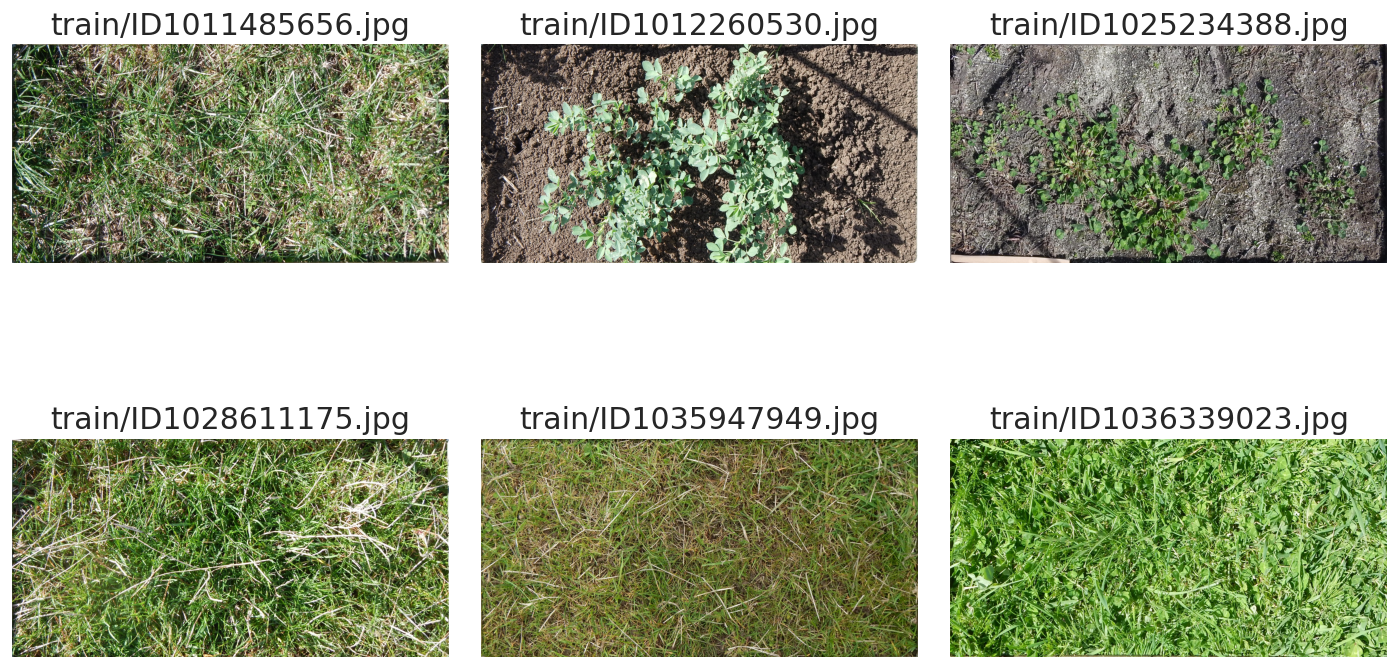

In [67]:
image_path = os.path.join(data_path)

sample_images= train_df["image_path"].unique()[:6]

plt.figure(figsize=(12,8))
for i , img_id in enumerate(sample_images):
    img = Image.open(os.path.join(image_path,img_id))
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_id)
plt.tight_layout()
plt.show()

In [68]:
train_df['target_name'].unique()

array(['Dry_Clover_g', 'Dry_Dead_g', 'Dry_Green_g', 'Dry_Total_g',
       'GDM_g'], dtype=object)

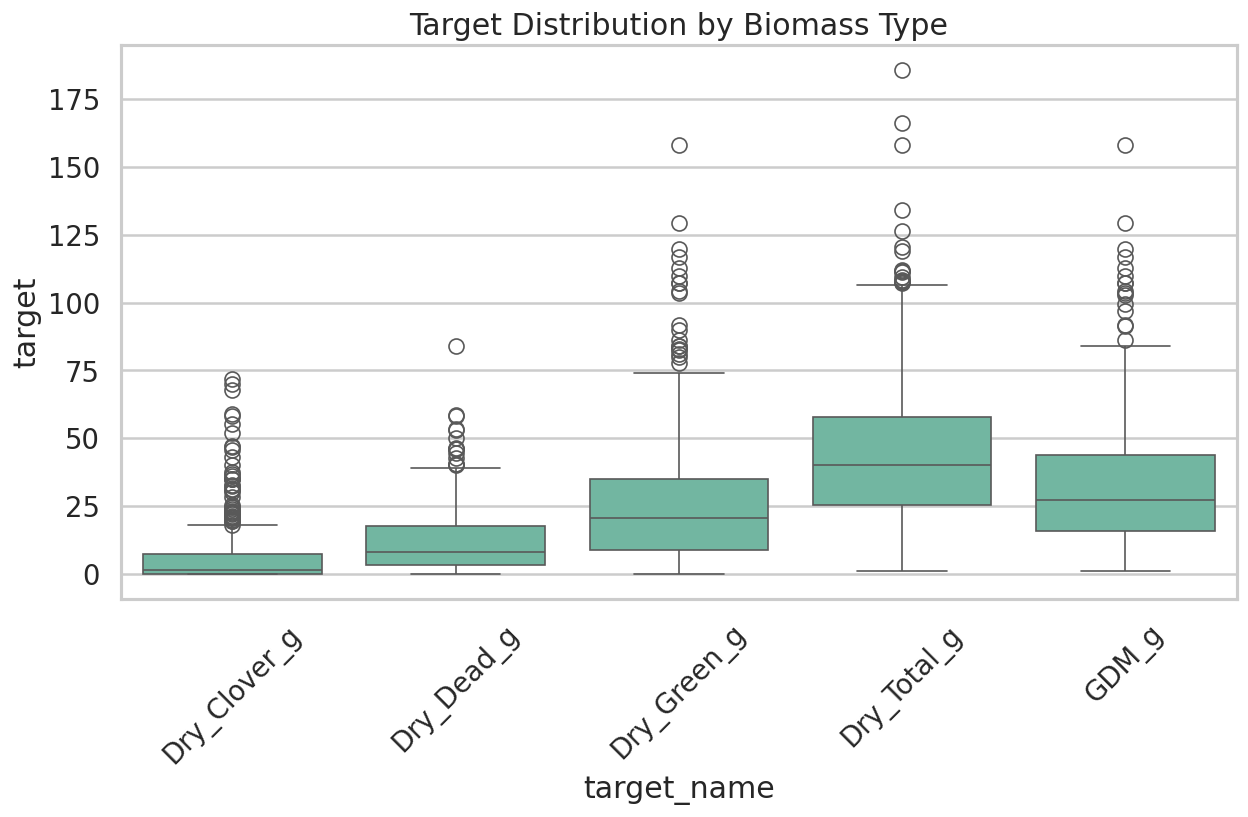

In [69]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data= train_df,
    x= "target_name",
    y = "target"
)
plt.xticks(rotation= 45)
plt.title("Target Distribution by Biomass Type")
plt.show()


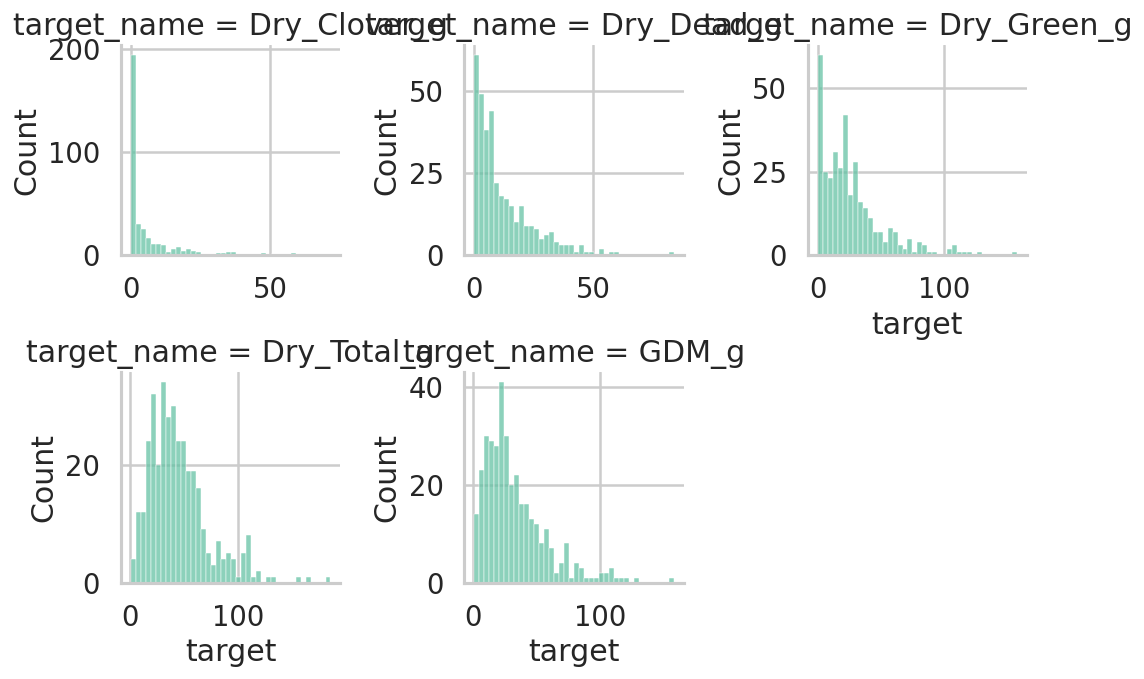

In [70]:
g = sns.FacetGrid(
    train_df,
    col="target_name",
    col_wrap=3,
    sharex=False,
    sharey=False
)

g.map(sns.histplot, "target", bins=40)
plt.show()


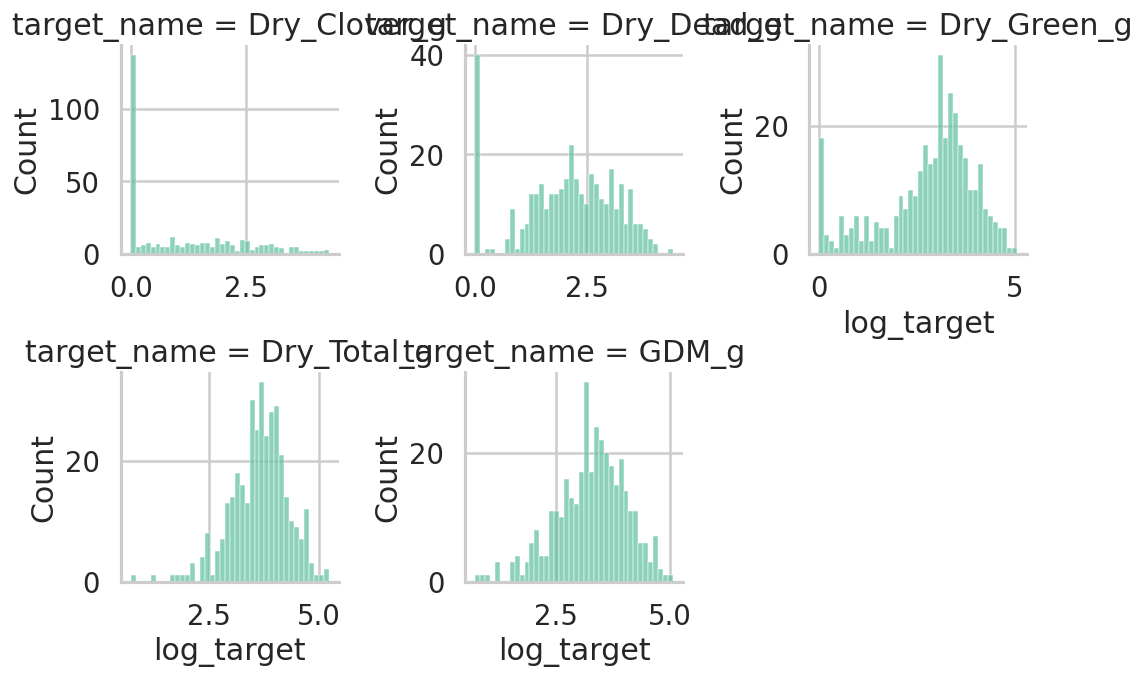

In [71]:
train_df["log_target"] = np.log1p(train_df["target"])

g = sns.FacetGrid(
    train_df,
    col="target_name",
    col_wrap=3,
    sharex=False,
    sharey=False
)

g.map(sns.histplot, "log_target", bins=40)
plt.show()


In [72]:
pivot_df = train_df.pivot(
    index="sample_id",
    columns="target_name",
    values="target"
)

pivot_df.head()


target_name,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
sample_id,,,,,
ID1011485656__Dry_Clover_g,0.0,NaN,NaN,NaN,NaN
ID1011485656__Dry_Dead_g,NaN,31.9984,NaN,NaN,NaN
ID1011485656__Dry_Green_g,NaN,NaN,16.2751,NaN,NaN
ID1011485656__Dry_Total_g,NaN,NaN,NaN,48.2735,NaN
ID1011485656__GDM_g,NaN,NaN,NaN,NaN,16.275


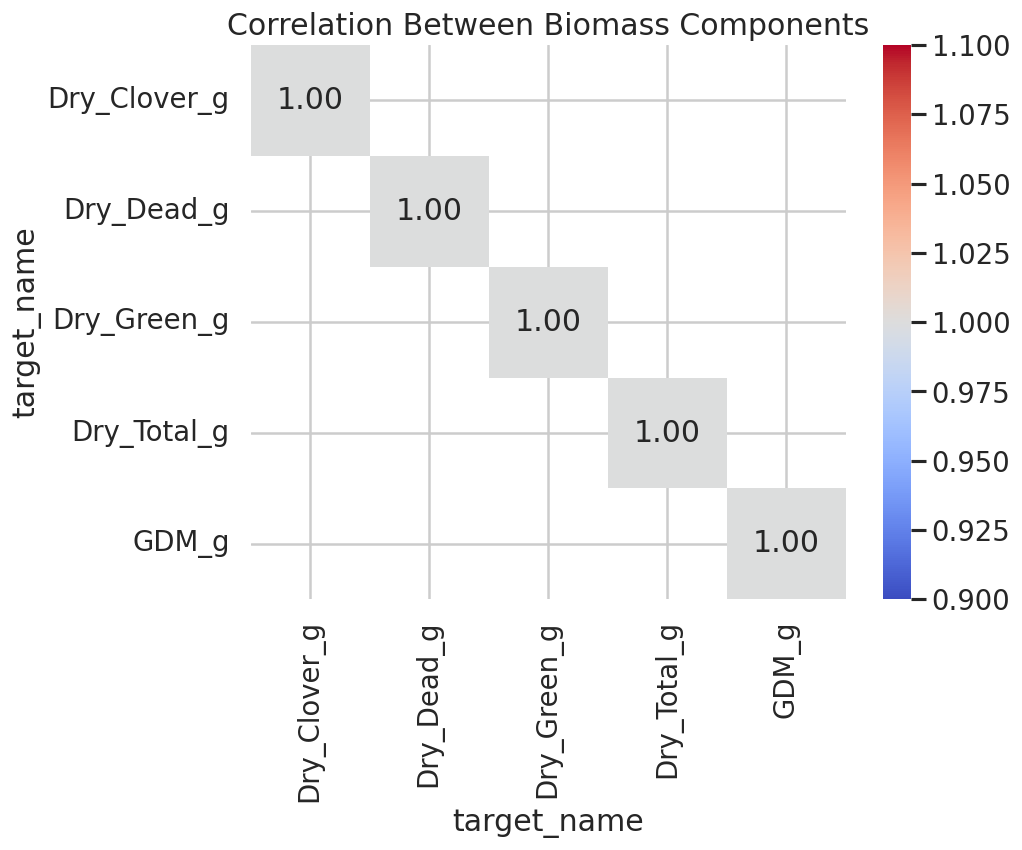

In [73]:
plt.figure(figsize=(8,6))
sns.heatmap(
    pivot_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Between Biomass Components")
plt.show()


In [74]:
train_df.isnull().sum()

sample_id        0
image_path       0
Sampling_Date    0
State            0
Species          0
Pre_GSHH_NDVI    0
Height_Ave_cm    0
target_name      0
target           0
log_target       0
dtype: int64

In [75]:
train_df

,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target,log_target
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Clover_g,0.0000,0.000000
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Dead_g,31.9984,3.496459
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Green_g,16.2751,2.849266
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Total_g,48.2735,3.897386
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,GDM_g,16.2750,2.849260
...,...,...,...,...,...,...,...,...,...,...
1780,ID983582017__Dry_Clover_g,train/ID983582017.jpg,2015/9/1,WA,Ryegrass,0.64,9.0000,Dry_Clover_g,0.0000,0.000000
1781,ID983582017__Dry_Dead_g,train/ID983582017.jpg,2015/9/1,WA,Ryegrass,0.64,9.0000,Dry_Dead_g,0.0000,0.000000
1782,ID983582017__Dry_Green_g,train/ID983582017.jpg,2015/9/1,WA,Ryegrass,0.64,9.0000,Dry_Green_g,40.9400,3.736240
1783,ID983582017__Dry_Total_g,train/ID983582017.jpg,2015/9/1,WA,Ryegrass,0.64,9.0000,Dry_Total_g,40.9400,3.736240


In [76]:
test_df

,sample_id,image_path,target_name
0,ID1001187975__Dry_Clover_g,test/ID1001187975.jpg,Dry_Clover_g
1,ID1001187975__Dry_Dead_g,test/ID1001187975.jpg,Dry_Dead_g
2,ID1001187975__Dry_Green_g,test/ID1001187975.jpg,Dry_Green_g
3,ID1001187975__Dry_Total_g,test/ID1001187975.jpg,Dry_Total_g
4,ID1001187975__GDM_g,test/ID1001187975.jpg,GDM_g


“The main predictive features are State, Species, NDVI, and Height.
target_name defines the task, target is the label.
The remaining columns are structural and control variables.”

In [77]:
continuous_features = ["Pre_GSHH_NDVI",
    "Height_Ave_cm",
    "target"]

In [78]:
def continuous_data_quality(df, features):
    rows = []

    n_total = len(df)

    for col in features:
        series = df[col]

        count = series.notna().sum()
        miss_pct = 100 * series.isna().sum() / n_total
        card = series.nunique()

        stats = series.describe()

        rows.append({
            "Feature": col,
            "Count": count,
            "% Miss.": round(miss_pct, 2),
            "Card.": card,
            "Min": round(stats["min"], 4),
            "1st Qrt.": round(stats["25%"], 4),
            "Mean": round(stats["mean"], 4),
            "Median": round(stats["50%"], 4),
            "3rd Qrt.": round(stats["75%"], 4),
            "Max": round(stats["max"], 4),
            "Std. Dev.": round(series.std(), 4)
        })

    return pd.DataFrame(rows)


In [79]:
continuous_quality_table = continuous_data_quality(
    train_df,
    continuous_features
)

continuous_quality_table


,Feature,Count,% Miss.,Card.,Min,1st Qrt.,Mean,Median,3rd Qrt.,Max,Std. Dev.
0,Pre_GSHH_NDVI,1785,0.0,65,0.16,0.5600,0.6574,0.69,0.7700,0.91,0.1520
1,Height_Ave_cm,1785,0.0,81,1.00,3.0000,7.5960,4.00,7.0000,70.00,10.2737
2,target,1785,0.0,1328,0.00,4.8182,24.7823,18.20,35.9406,185.70,25.8237


In [80]:
styled_continuous = (
    continuous_quality_table
    .style
    .set_caption("Data Quality Report – Continuous Features")
    .format({
        "Count": "{:,.0f}",
        "% Miss.": "{:.2f}%",
        "Card.": "{:,}",
        "Min": "{:.4f}",
        "1st Qrt.": "{:.4f}",
        "Mean": "{:.4f}",
        "Median": "{:.4f}",
        "3rd Qrt.": "{:.4f}",
        "Max": "{:.4f}",
        "Std. Dev.": "{:.4f}",
    })
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "16px"),
                                          ("font-weight", "bold"),
                                          ("text-align", "center")]},
        {"selector": "th", "props": [("font-weight", "bold"),
                                     ("background-color", "#f2f2f2")]},
        {"selector": "td", "props": [("text-align", "center")]}
    ])
)

styled_continuous


,Feature,Count,% Miss.,Card.,Min,1st Qrt.,Mean,Median,3rd Qrt.,Max,Std. Dev.
0,Pre_GSHH_NDVI,"1,785",0.00%,65,0.1600,0.5600,0.6574,0.6900,0.7700,0.9100,0.1520
1,Height_Ave_cm,"1,785",0.00%,81,1.0000,3.0000,7.5960,4.0000,7.0000,70.0000,10.2737
2,target,"1,785",0.00%,"1,328",0.0000,4.8182,24.7823,18.2000,35.9406,185.7000,25.8237


LATEX TABLE


In [81]:
latex_table = continuous_quality_table.to_latex(
    index=False,
    float_format="%.4f",
    caption="Data Quality Report for Continuous Features",
    label="tab:data_quality_continuous"
)

print(latex_table)


\begin{table}
\caption{Data Quality Report for Continuous Features}
\label{tab:data_quality_continuous}
\begin{tabular}{lrrrrrrrrrr}
\toprule
Feature & Count & % Miss. & Card. & Min & 1st Qrt. & Mean & Median & 3rd Qrt. & Max & Std. Dev. \\
\midrule
Pre_GSHH_NDVI & 1785 & 0.0000 & 65 & 0.1600 & 0.5600 & 0.6574 & 0.6900 & 0.7700 & 0.9100 & 0.1520 \\
Height_Ave_cm & 1785 & 0.0000 & 81 & 1.0000 & 3.0000 & 7.5960 & 4.0000 & 7.0000 & 70.0000 & 10.2737 \\
target & 1785 & 0.0000 & 1328 & 0.0000 & 4.8182 & 24.7823 & 18.2000 & 35.9406 & 185.7000 & 25.8237 \\
\bottomrule
\end{tabular}
\end{table}



In [82]:
md_table = continuous_quality_table.to_markdown(index=False)
print(md_table)


| Feature       |   Count |   % Miss. |   Card. |   Min |   1st Qrt. |    Mean |   Median |   3rd Qrt. |    Max |   Std. Dev. |
|:--------------|--------:|----------:|--------:|------:|-----------:|--------:|---------:|-----------:|-------:|------------:|
| Pre_GSHH_NDVI |    1785 |         0 |      65 |  0.16 |     0.56   |  0.6574 |     0.69 |     0.77   |   0.91 |      0.152  |
| Height_Ave_cm |    1785 |         0 |      81 |  1    |     3      |  7.596  |     4    |     7      |  70    |     10.2737 |
| target        |    1785 |         0 |    1328 |  0    |     4.8182 | 24.7823 |    18.2  |    35.9406 | 185.7  |     25.8237 |


In [83]:
def highlight_missing(val):
    if val > 5:
        return "background-color: #ffcccc"
    elif val > 1:
        return "background-color: #fff2cc"
    return ""

styled_continuous = (
    continuous_quality_table
    .style
    .applymap(highlight_missing, subset=["% Miss."])
    .set_caption("Data Quality Report – Continuous Features")
)

styled_continuous


/tmp/ipykernel_55/491601582.py:11: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(highlight_missing, subset=["% Miss."])


,Feature,Count,% Miss.,Card.,Min,1st Qrt.,Mean,Median,3rd Qrt.,Max,Std. Dev.
0,Pre_GSHH_NDVI,1785,0.000000,65,0.160000,0.560000,0.657400,0.690000,0.770000,0.910000,0.152000
1,Height_Ave_cm,1785,0.000000,81,1.000000,3.000000,7.596000,4.000000,7.000000,70.000000,10.273700
2,target,1785,0.000000,1328,0.000000,4.818200,24.782300,18.200000,35.940600,185.700000,25.823700


In [84]:
# Categorical features (including task identifier)
categorical_features = [
    "State",
    "Species",
    "target_name"
]


In [85]:
def categorical_data_quality(df, features):
    rows = []
    n_total = len(df)

    for col in features:
        series = df[col]

        count = series.notna().sum()
        miss_pct = 100 * series.isna().sum() / n_total
        card = series.nunique(dropna=True)

        value_counts = series.value_counts(dropna=True)

        # Mode
        mode = value_counts.index[0]
        mode_freq = value_counts.iloc[0]
        mode_pct = 100 * mode_freq / count

        # Second mode (if exists)
        if len(value_counts) > 1:
            second_mode = value_counts.index[1]
            second_freq = value_counts.iloc[1]
            second_pct = 100 * second_freq / count
        else:
            second_mode = np.nan
            second_freq = np.nan
            second_pct = np.nan

        rows.append({
            "Feature": col,
            "Count": count,
            "% Miss.": round(miss_pct, 2),
            "Card.": card,
            "Mode": mode,
            "Mode Freq.": mode_freq,
            "Mode %": round(mode_pct, 2),
            "2nd Mode": second_mode,
            "2nd Freq.": second_freq,
            "2nd %": round(second_pct, 2) if not np.isnan(second_pct) else np.nan
        })

    return pd.DataFrame(rows)


In [86]:
categorical_quality_table = categorical_data_quality(
    train_df,
    categorical_features
)

categorical_quality_table


,Feature,Count,% Miss.,Card.,Mode,Mode Freq.,Mode %,2nd Mode,2nd Freq.,2nd %
0,State,1785,0.0,4,Tas,690,38.66,Vic,560,31.37
1,Species,1785,0.0,15,Ryegrass_Clover,490,27.45,Ryegrass,310,17.37
2,target_name,1785,0.0,5,Dry_Clover_g,357,20.00,Dry_Dead_g,357,20.00


In [87]:
styled_categorical = (
    categorical_quality_table
    .style
    .set_caption("Data Quality Report – Categorical Features")
    .format({
        "% Miss.": "{:.2f}%",
        "Mode %": "{:.2f}%",
        "2nd %": "{:.2f}%"
    })
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "16px"),
                                          ("font-weight", "bold"),
                                          ("text-align", "center")]},
        {"selector": "th", "props": [("font-weight", "bold"),
                                     ("background-color", "#f2f2f2")]},
        {"selector": "td", "props": [("text-align", "center")]}
    ])
)

styled_categorical


,Feature,Count,% Miss.,Card.,Mode,Mode Freq.,Mode %,2nd Mode,2nd Freq.,2nd %
0,State,1785,0.00%,4,Tas,690,38.66%,Vic,560,31.37%
1,Species,1785,0.00%,15,Ryegrass_Clover,490,27.45%,Ryegrass,310,17.37%
2,target_name,1785,0.00%,5,Dry_Clover_g,357,20.00%,Dry_Dead_g,357,20.00%


In [88]:
def highlight_dominance(val):
    if val > 80:
        return "background-color: #ffcccc"
    elif val > 50:
        return "background-color: #fff2cc"
    return ""

styled_categorical = (
    categorical_quality_table
    .style
    .applymap(highlight_dominance, subset=["Mode %"])
    .set_caption("Data Quality Report – Categorical Features")
)

styled_categorical


/tmp/ipykernel_55/174998798.py:11: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(highlight_dominance, subset=["Mode %"])


,Feature,Count,% Miss.,Card.,Mode,Mode Freq.,Mode %,2nd Mode,2nd Freq.,2nd %
0,State,1785,0.000000,4,Tas,690,38.660000,Vic,560,31.370000
1,Species,1785,0.000000,15,Ryegrass_Clover,490,27.450000,Ryegrass,310,17.370000
2,target_name,1785,0.000000,5,Dry_Clover_g,357,20.000000,Dry_Dead_g,357,20.000000


In [89]:
markdown_table = categorical_quality_table.to_markdown(index=False)
print(markdown_table)


| Feature     |   Count |   % Miss. |   Card. | Mode            |   Mode Freq. |   Mode % | 2nd Mode   |   2nd Freq. |   2nd % |
|:------------|--------:|----------:|--------:|:----------------|-------------:|---------:|:-----------|------------:|--------:|
| State       |    1785 |         0 |       4 | Tas             |          690 |    38.66 | Vic        |         560 |   31.37 |
| Species     |    1785 |         0 |      15 | Ryegrass_Clover |          490 |    27.45 | Ryegrass   |         310 |   17.37 |
| target_name |    1785 |         0 |       5 | Dry_Clover_g    |          357 |    20    | Dry_Dead_g |         357 |   20    |


Bar Plots and Histograms for respective data 

In [90]:
# Create log target for visualization
train_df["log_target"] = np.log1p(train_df["target"])


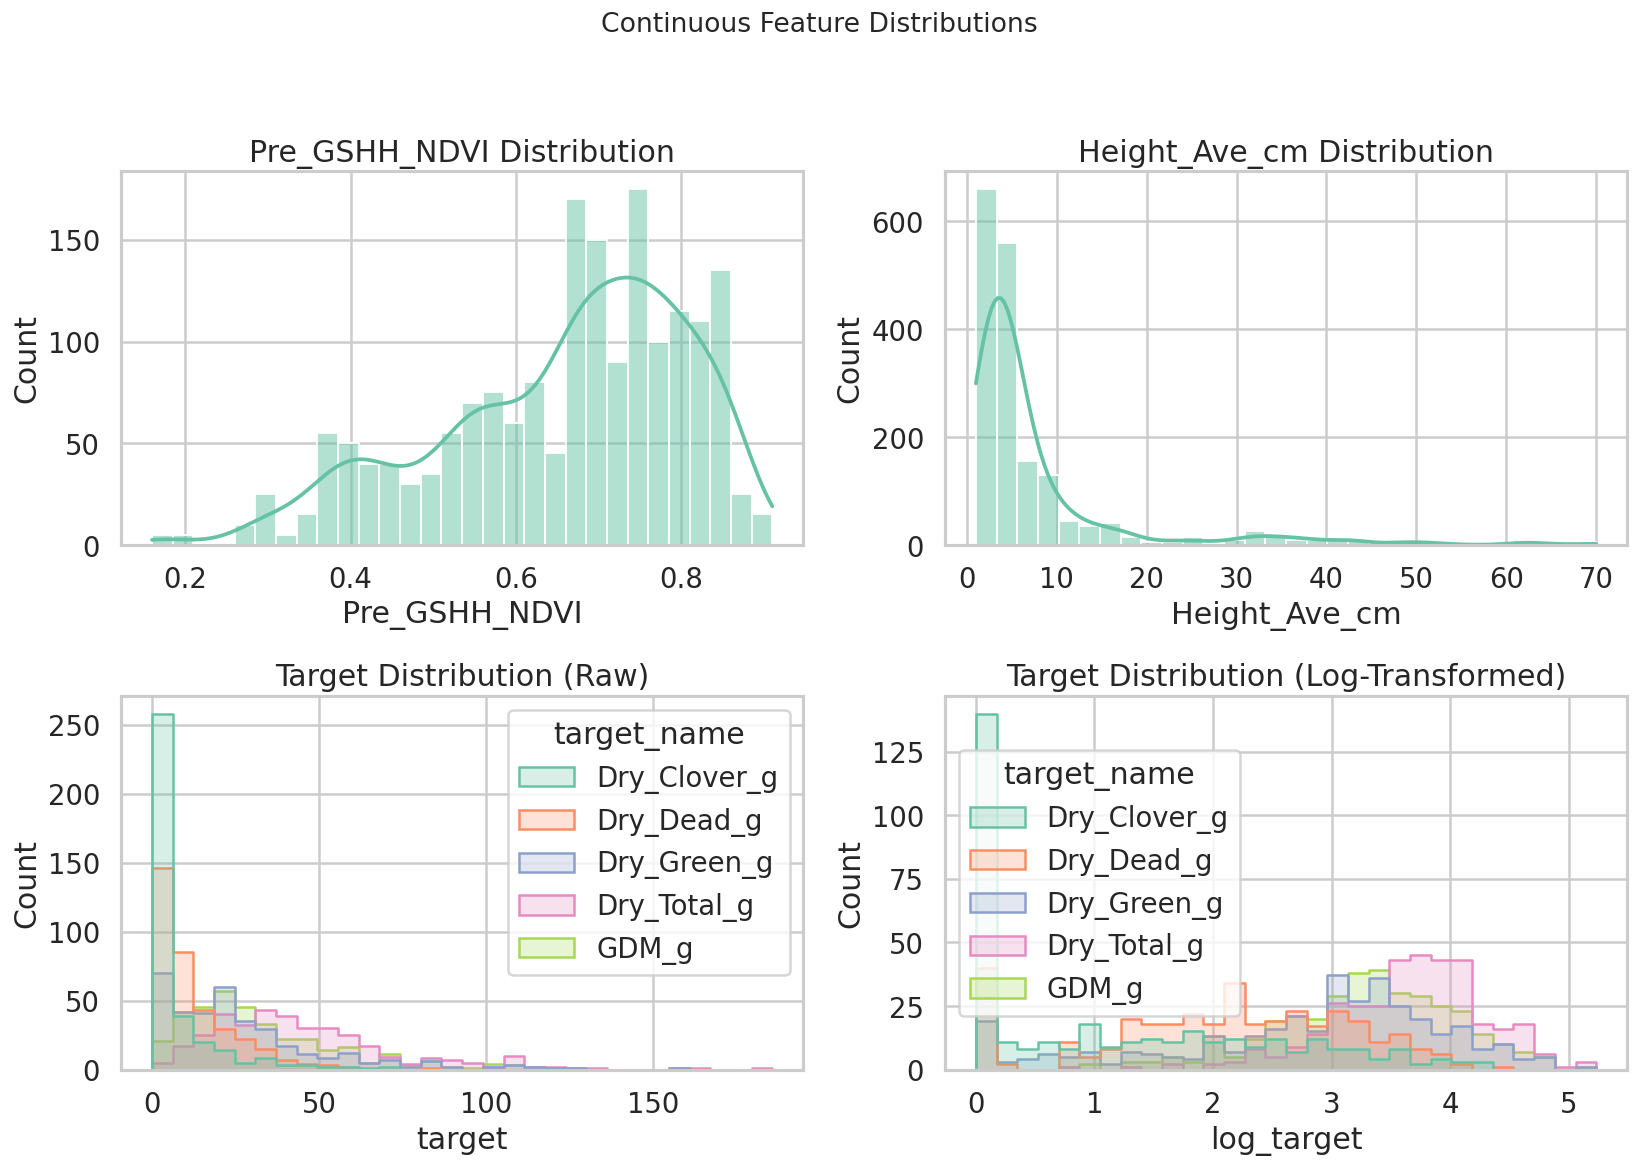

In [91]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Continuous Feature Distributions", fontsize=16)

# NDVI
sns.histplot(train_df["Pre_GSHH_NDVI"], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Pre_GSHH_NDVI Distribution")

# Height
sns.histplot(train_df["Height_Ave_cm"], bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Height_Ave_cm Distribution")

# Raw target
sns.histplot(
    data=train_df,
    x="target",
    hue="target_name",
    bins=30,
    element="step",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Target Distribution (Raw)")

# Log-transformed target
sns.histplot(
    data=train_df,
    x="log_target",
    hue="target_name",
    bins=30,
    element="step",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Target Distribution (Log-Transformed)")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


/tmp/ipykernel_55/3810996743.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


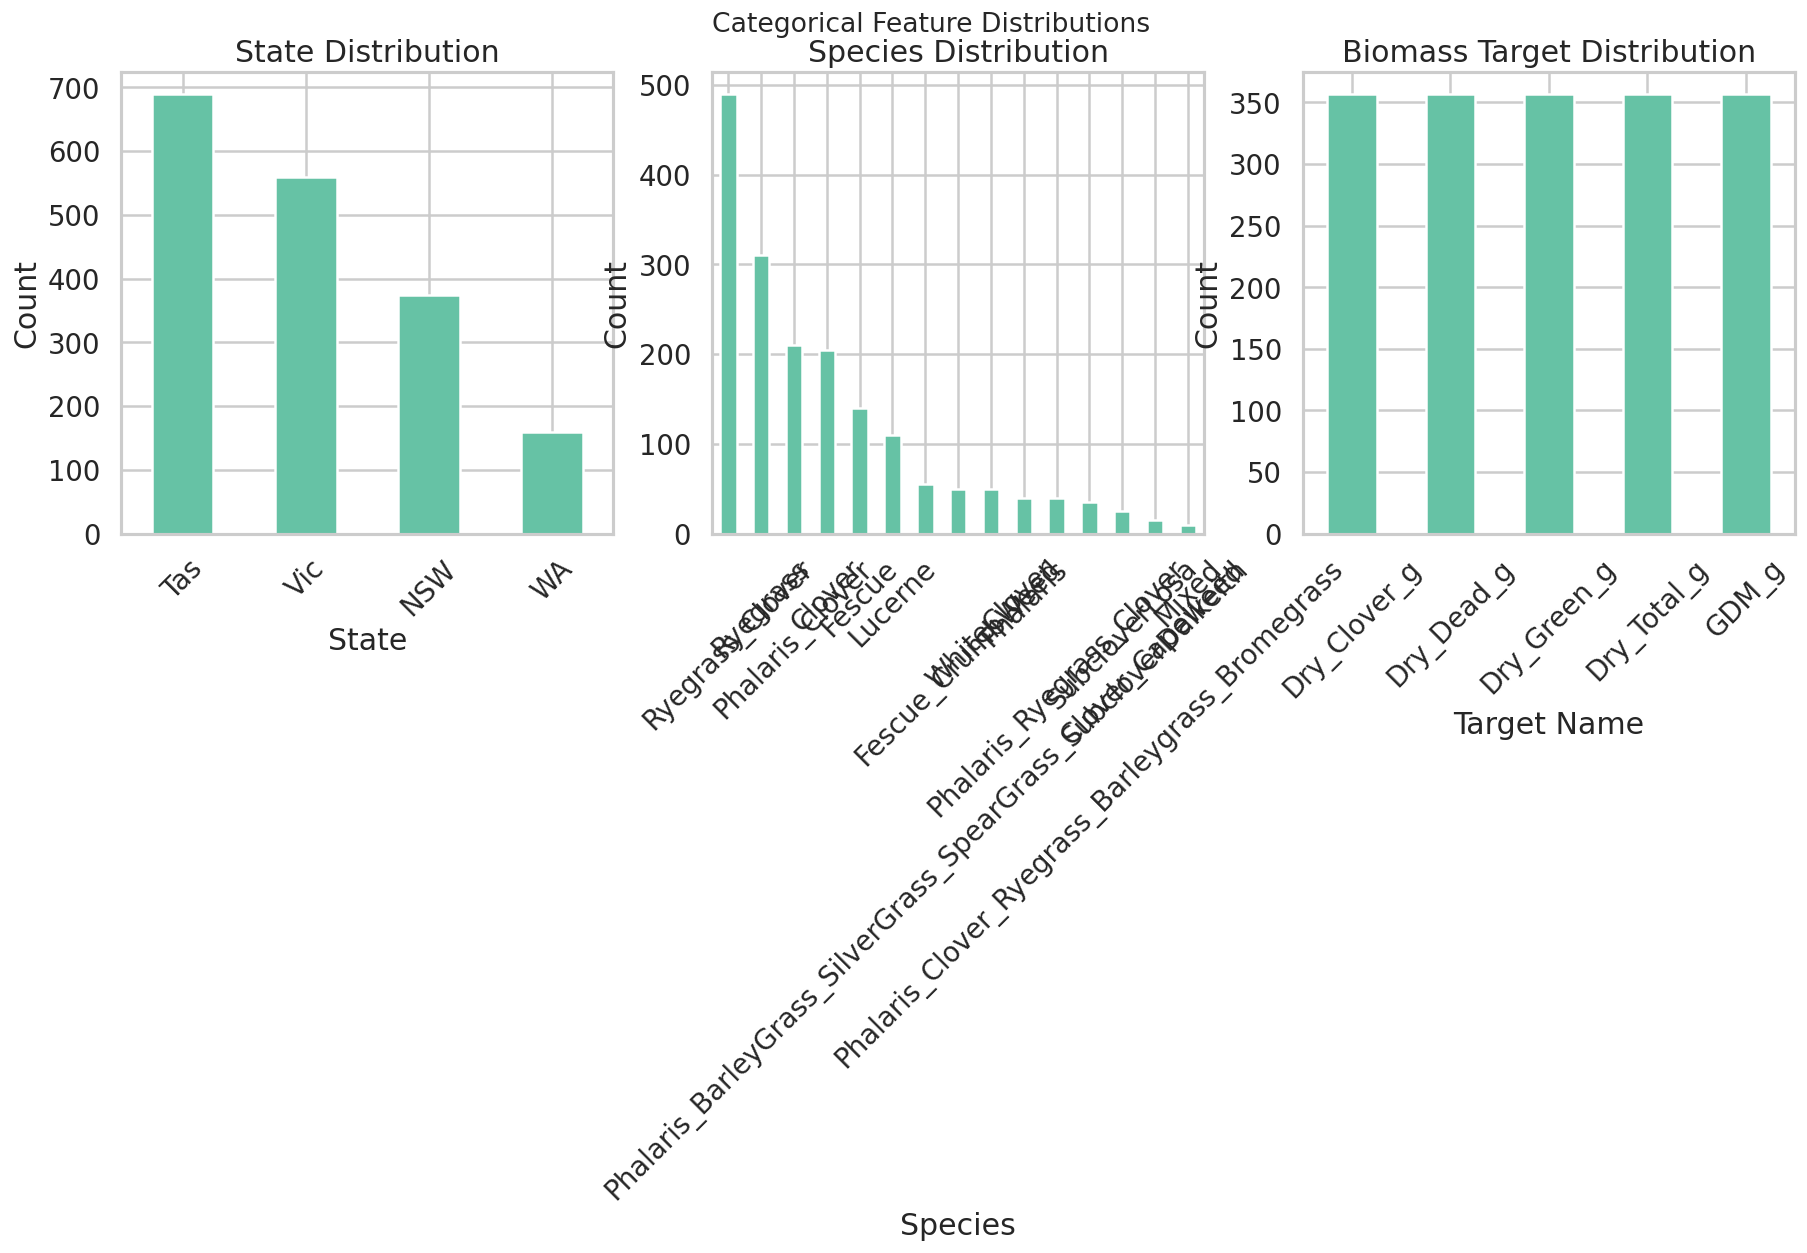

In [92]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Categorical Feature Distributions", fontsize=16)

# State
train_df["State"].value_counts().plot(
    kind="bar",
    ax=axes[0]
)
axes[0].set_title("State Distribution")
axes[0].set_xlabel("State")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Species
train_df["Species"].value_counts().plot(
    kind="bar",
    ax=axes[1]
)
axes[1].set_title("Species Distribution")
axes[1].set_xlabel("Species")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

# Target Name
train_df["target_name"].value_counts().plot(
    kind="bar",
    ax=axes[2]
)
axes[2].set_title("Biomass Target Distribution")
axes[2].set_xlabel("Target Name")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    context="talk",   # better font sizes
    palette="Set2"    # clean, colorblind-safe palette
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300


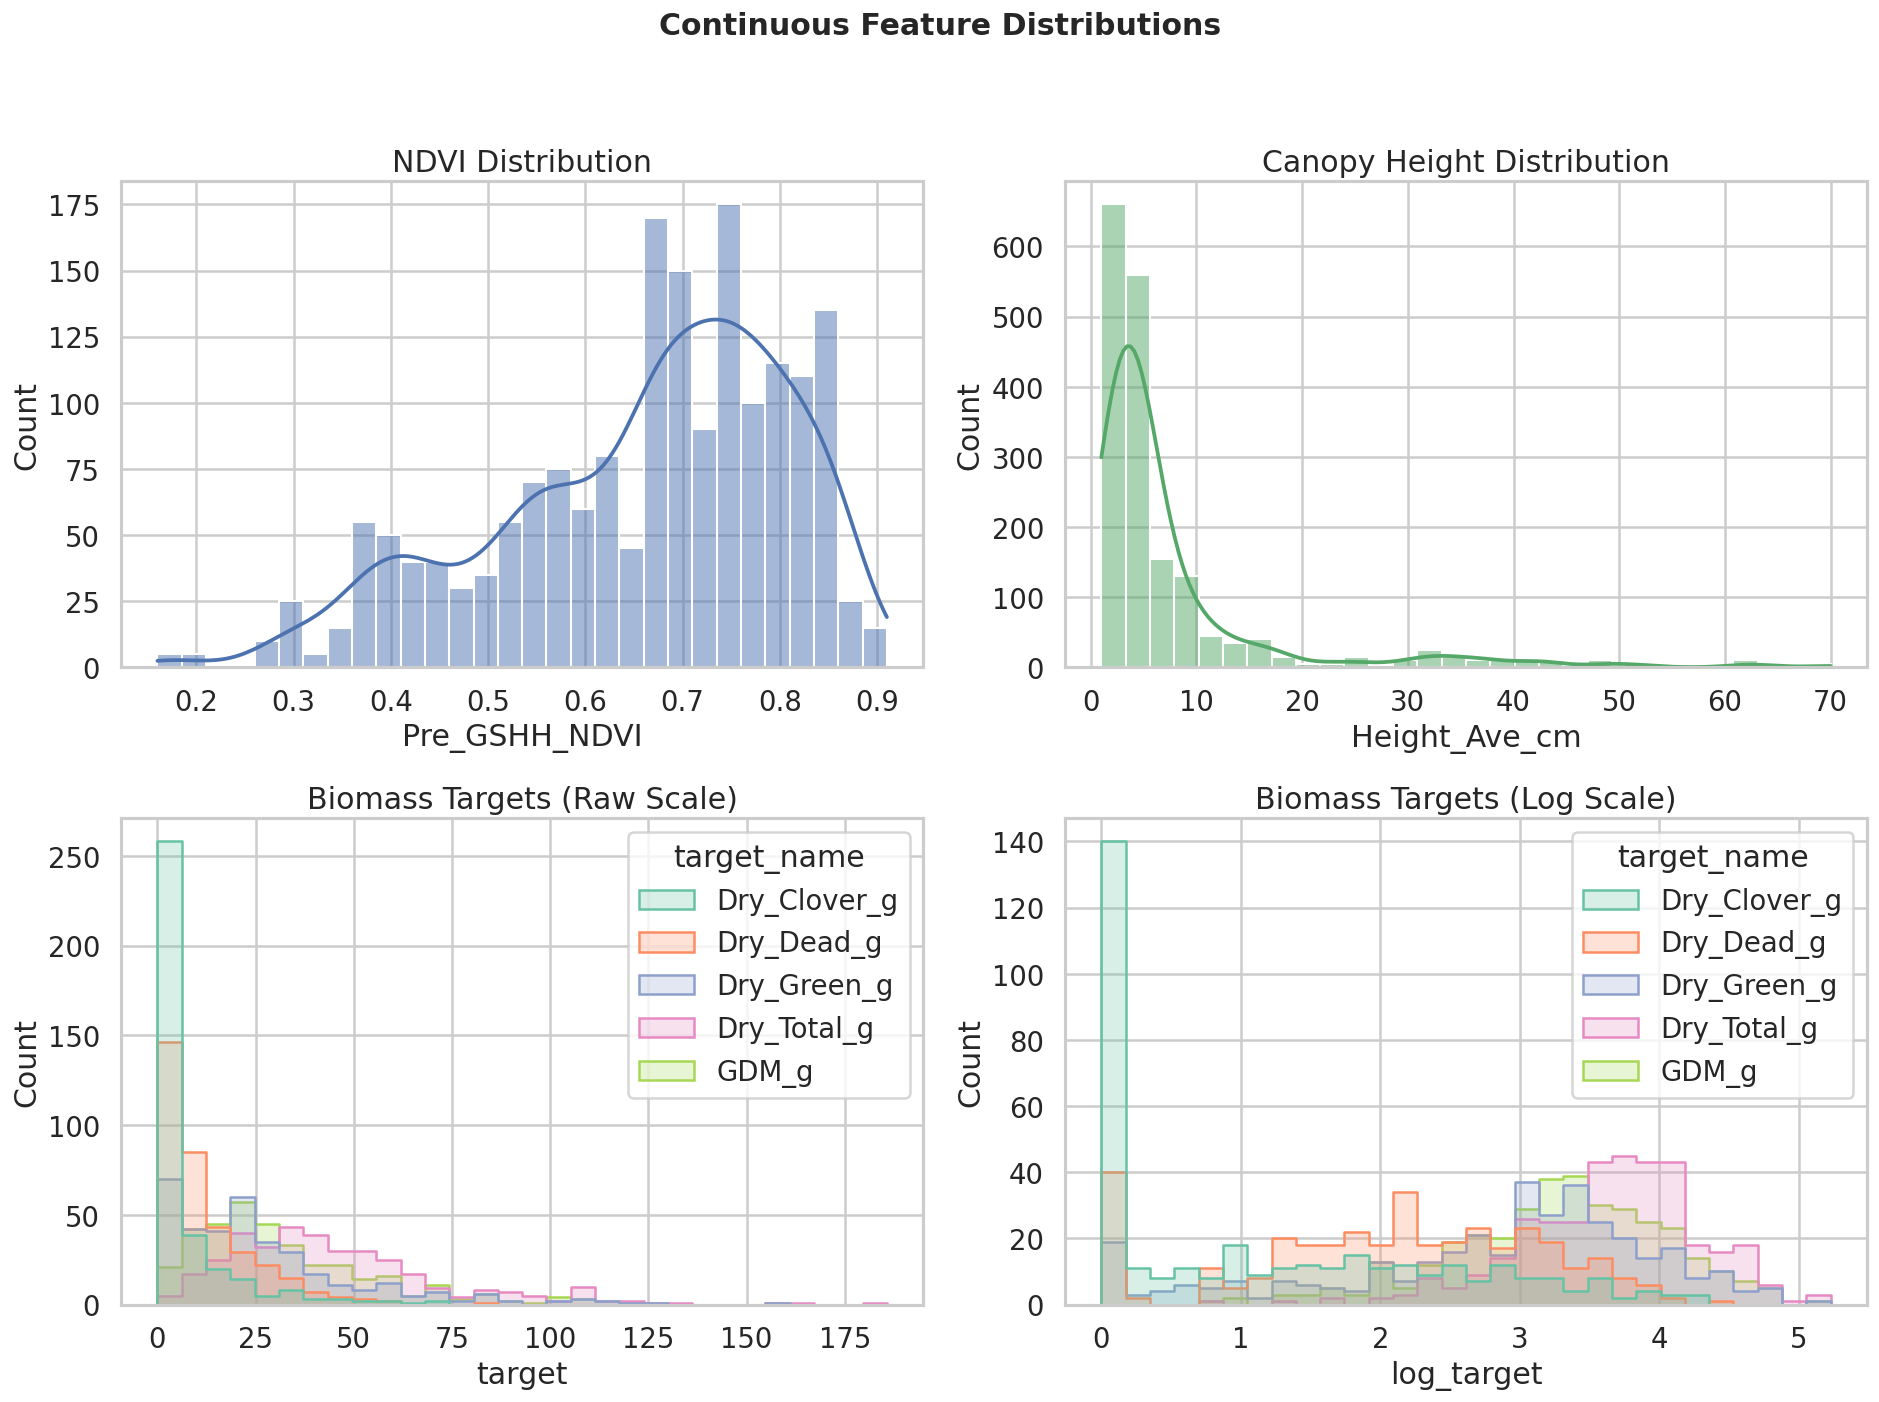

In [94]:
import numpy as np

train_df["log_target"] = np.log1p(train_df["target"])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Continuous Feature Distributions", fontsize=18, weight="bold")

# NDVI
sns.histplot(
    train_df["Pre_GSHH_NDVI"],
    bins=30,
    kde=True,
    color="#4C72B0",
    ax=axes[0, 0]
)
axes[0, 0].set_title("NDVI Distribution")

# Height
sns.histplot(
    train_df["Height_Ave_cm"],
    bins=30,
    kde=True,
    color="#55A868",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Canopy Height Distribution")

# Raw target
sns.histplot(
    data=train_df,
    x="target",
    hue="target_name",
    bins=30,
    element="step",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Biomass Targets (Raw Scale)")

# Log target
sns.histplot(
    data=train_df,
    x="log_target",
    hue="target_name",
    bins=30,
    element="step",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Biomass Targets (Log Scale)")

plt.tight_layout(rect=[0, 0, 1, 0.95])

# SAVE
plt.savefig("continuous_features_distribution.png", bbox_inches="tight")
plt.show()


/tmp/ipykernel_55/1540975775.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_55/1540975775.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_55/1540975775.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_55/1540975775.py:39: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


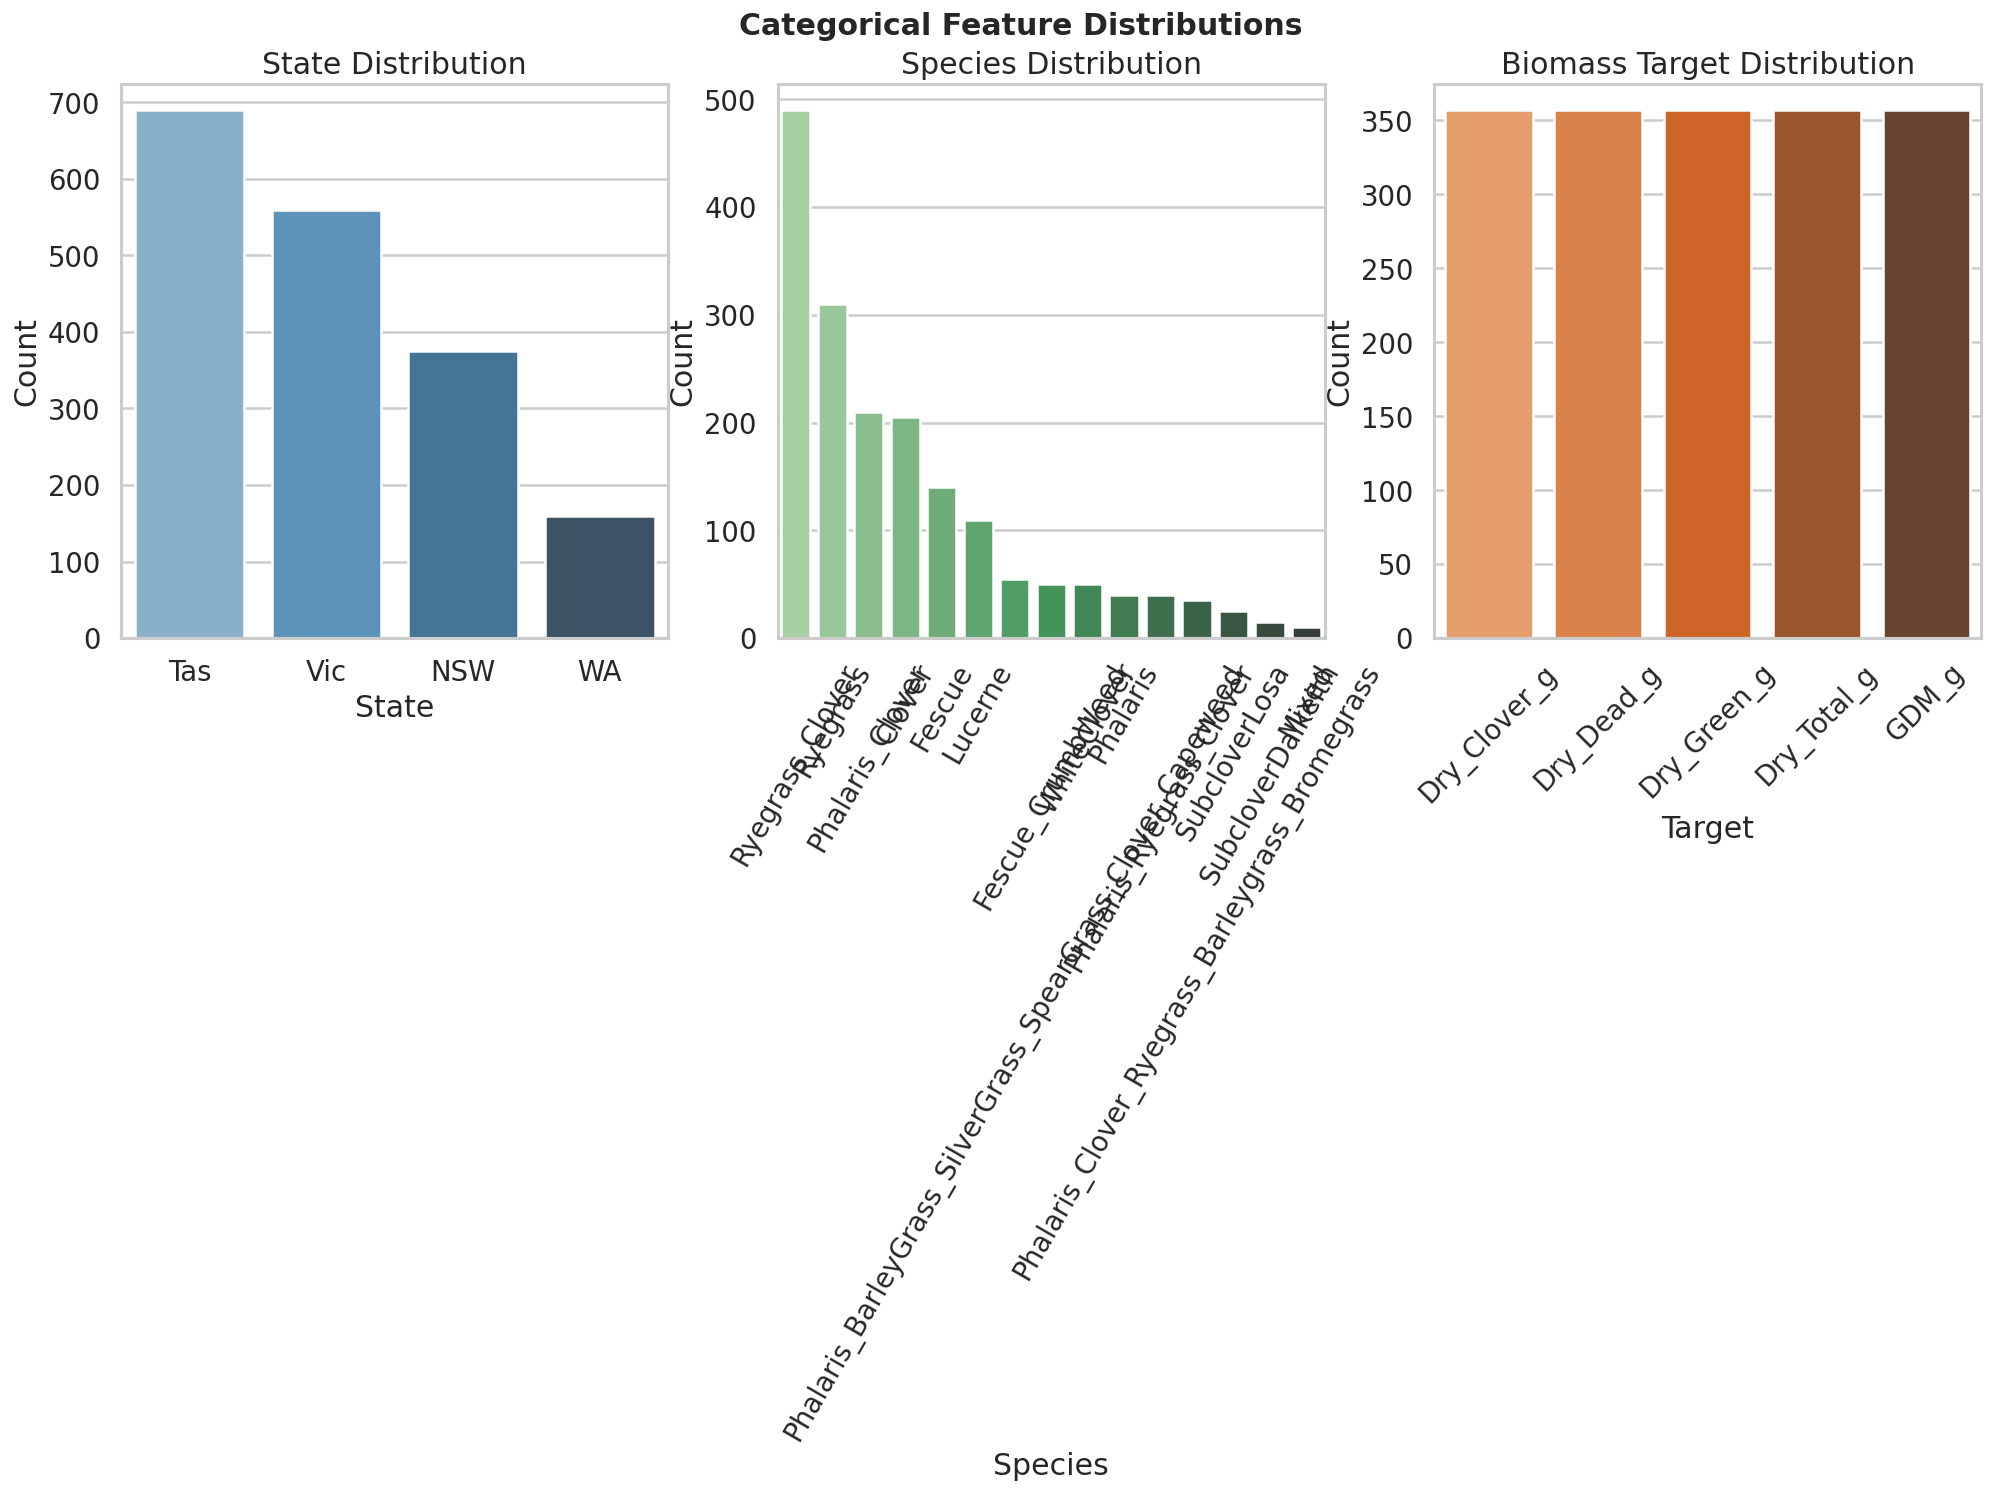

In [95]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Categorical Feature Distributions", fontsize=18, weight="bold")

# State
sns.barplot(
    x=train_df["State"].value_counts().index,
    y=train_df["State"].value_counts().values,
    palette="Blues_d",
    ax=axes[0]
)
axes[0].set_title("State Distribution")
axes[0].set_xlabel("State")
axes[0].set_ylabel("Count")

# Species
sns.barplot(
    x=train_df["Species"].value_counts().index,
    y=train_df["Species"].value_counts().values,
    palette="Greens_d",
    ax=axes[1]
)
axes[1].set_title("Species Distribution")
axes[1].set_xlabel("Species")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=60)

# Target name
sns.barplot(
    x=train_df["target_name"].value_counts().index,
    y=train_df["target_name"].value_counts().values,
    palette="Oranges_d",
    ax=axes[2]
)
axes[2].set_title("Biomass Target Distribution")
axes[2].set_xlabel("Target")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# SAVE
plt.savefig("categorical_features_distribution.png", bbox_inches="tight")
plt.show()


In [96]:
# Number of top categories to show
TOP_K = 8

species_counts = train_df["Species"].value_counts()

# Split top-K and others
top_species = species_counts.head(TOP_K)
other_count = species_counts.iloc[TOP_K:].sum()

# Combine into a new series
species_plot_data = top_species.copy()
species_plot_data["Other"] = other_count


/tmp/ipykernel_55/4130008293.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


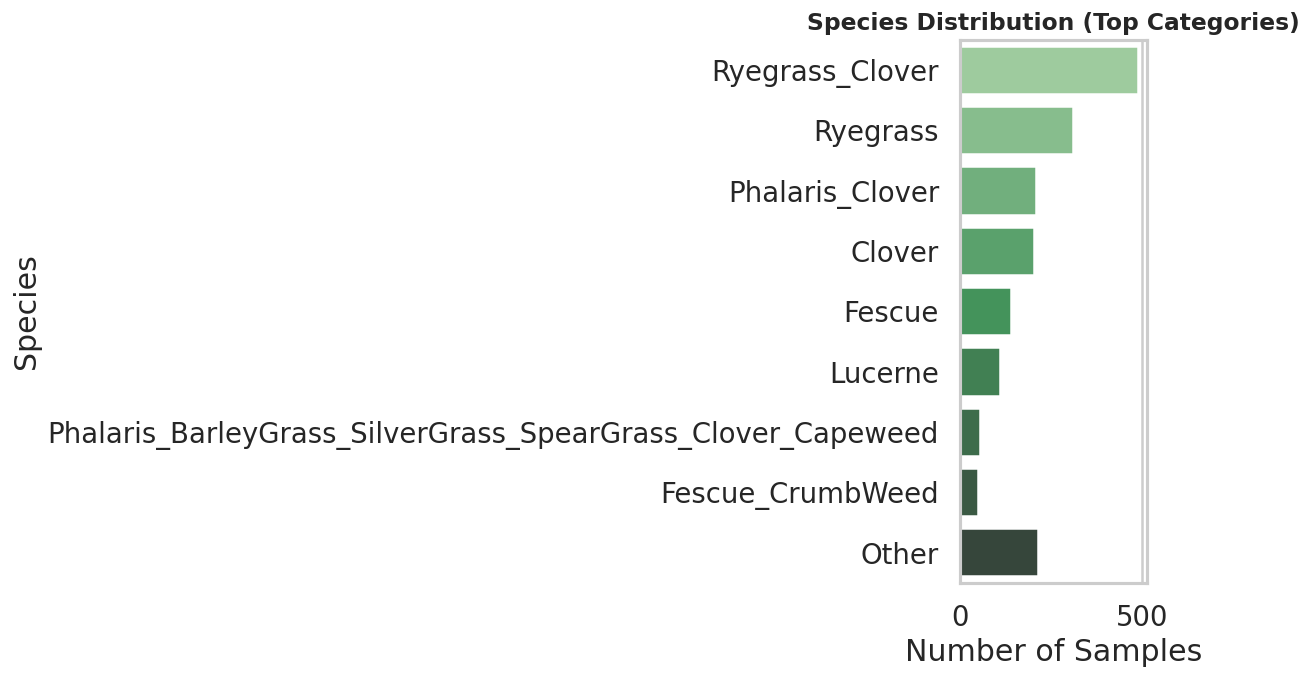

In [97]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=species_plot_data.values,
    y=species_plot_data.index,
    palette="Greens_d"
)

plt.title("Species Distribution (Top Categories)", fontsize=14, weight="bold")
plt.xlabel("Number of Samples")
plt.ylabel("Species")

plt.tight_layout()
plt.show()


/tmp/ipykernel_55/2567653074.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


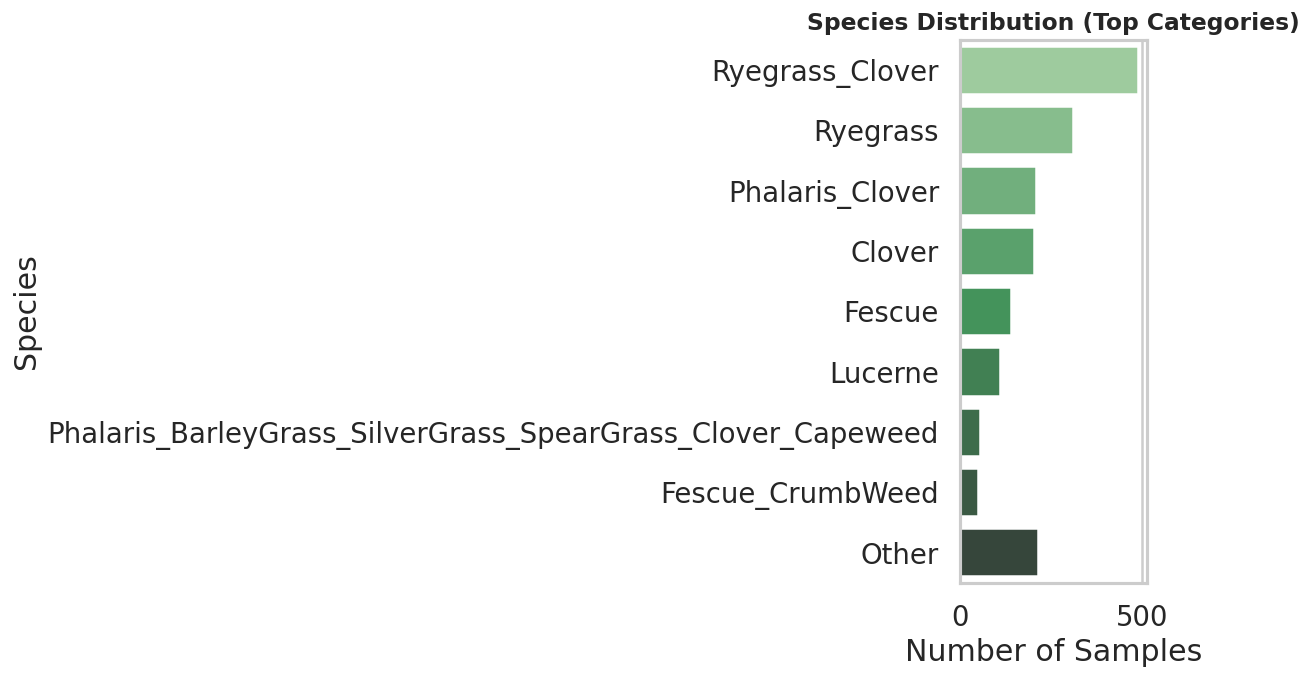

In [98]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=species_plot_data.values,
    y=species_plot_data.index,
    palette="Greens_d"
)

plt.title("Species Distribution (Top Categories)", fontsize=14, weight="bold")
plt.xlabel("Number of Samples")
plt.ylabel("Species")

plt.tight_layout()
plt.savefig("species_distribution_clean.png", dpi=300, bbox_inches="tight")
plt.show()


In [99]:
test_df

,sample_id,image_path,target_name
0,ID1001187975__Dry_Clover_g,test/ID1001187975.jpg,Dry_Clover_g
1,ID1001187975__Dry_Dead_g,test/ID1001187975.jpg,Dry_Dead_g
2,ID1001187975__Dry_Green_g,test/ID1001187975.jpg,Dry_Green_g
3,ID1001187975__Dry_Total_g,test/ID1001187975.jpg,Dry_Total_g
4,ID1001187975__GDM_g,test/ID1001187975.jpg,GDM_g


As in test_df , we only have image and target name , so we have to opt for image - based models. We have options like CNN. First we would go with this , then we can move on to a good image based model or any hybrid model .


In [100]:
import os 
import numpy as np
import pandas as pd
from PIL import Image 

import torch
import torch.nn as nn
from torch.utils.data import Dataset , DataLoader
from torchvision import models , transforms

In [101]:
TARGETS = [
    "Dry_Clover_g",
    "Dry_Dead_g",
    "Dry_Green_g",
    "GDM_g",
    "Dry_Total_g"
]

target2idx = {t: i for i, t in enumerate(TARGETS)}


In [102]:
pivot_df = train_df.pivot(
    index="image_path",
    columns="target_name",
    values="target"
).reset_index()

In [103]:
pivot_df

target_name,image_path,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
0,train/ID1011485656.jpg,0.0000,31.9984,16.2751,48.2735,16.2750
1,train/ID1012260530.jpg,0.0000,0.0000,7.6000,7.6000,7.6000
2,train/ID1025234388.jpg,6.0500,0.0000,0.0000,6.0500,6.0500
3,train/ID1028611175.jpg,0.0000,30.9703,24.2376,55.2079,24.2376
4,train/ID1035947949.jpg,0.4343,23.2239,10.5261,34.1844,10.9605
...,...,...,...,...,...,...
352,train/ID975115267.jpg,40.0300,0.0000,0.8000,40.8300,40.8300
353,train/ID978026131.jpg,24.6445,4.1948,12.0601,40.8994,36.7046
354,train/ID980538882.jpg,0.0000,1.1457,91.6543,92.8000,91.6543
355,train/ID980878870.jpg,32.3575,0.0000,2.0325,34.3900,34.3900


In [104]:
class BiomassDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["image_path"])
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        targets = row[TARGETS].values.astype(np.float32)
        targets = np.log1p(targets)  # log-space

        return image, torch.tensor(targets)


In [105]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [106]:
class BiomassCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(pretrained=False)
        self.backbone.fc = nn.Identity()
        self.head = nn.Linear(512, 5)

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)


In [107]:
device = "cuda" if torch.cuda.is_available() else "cpu"

dataset = BiomassDataset(
    pivot_df,
    img_dir="/kaggle/input/csiro-biomass",
    transform=transform
)

loader = DataLoader(dataset, batch_size=16, shuffle=True)

model = BiomassCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [109]:
max_epochs = 20
patience = 3          # stop after 3 non-improving epochs
min_delta = 1e-4      # minimum improvement to be considered meaningful



In [110]:
best_loss = float("inf")
epochs_no_improve = 0
best_model_state = None

model.train()

for epoch in range(max_epochs):
    total_loss = 0.0

    for images, targets in loader:
        images = images.to(device)
        targets = targets.to(device)

        preds = model(images)
        loss = criterion(preds, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

    # ---- Early Stopping Logic ----
    if best_loss - avg_loss > min_delta:
        best_loss = avg_loss
        epochs_no_improve = 0
        best_model_state = model.state_dict()
        print("  ↳ New best model saved")
    else:
        epochs_no_improve += 1
        print(f"  ↳ No improvement ({epochs_no_improve}/{patience})")

    if epochs_no_improve >= patience:
        print("⏹ Early stopping triggered")
        break



Epoch 1, Loss: 2.9820
  ↳ New best model saved
Epoch 2, Loss: 0.8538
  ↳ New best model saved
Epoch 3, Loss: 0.6485
  ↳ New best model saved
Epoch 4, Loss: 0.5293
  ↳ New best model saved
Epoch 5, Loss: 0.3989
  ↳ New best model saved
Epoch 6, Loss: 0.3339
  ↳ New best model saved
Epoch 7, Loss: 0.2943
  ↳ New best model saved
Epoch 8, Loss: 0.2267
  ↳ New best model saved
Epoch 9, Loss: 0.1472
  ↳ New best model saved
Epoch 10, Loss: 0.1391
  ↳ New best model saved
Epoch 11, Loss: 0.1284
  ↳ New best model saved
Epoch 12, Loss: 0.1310
  ↳ No improvement (1/3)
Epoch 13, Loss: 0.1148
  ↳ New best model saved
Epoch 14, Loss: 0.1174
  ↳ No improvement (1/3)
Epoch 15, Loss: 0.1104
  ↳ New best model saved
Epoch 16, Loss: 0.1250
  ↳ No improvement (1/3)
Epoch 17, Loss: 0.1104
  ↳ No improvement (2/3)
Epoch 18, Loss: 0.1110
  ↳ No improvement (3/3)
⏹ Early stopping triggered


In [111]:
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("✅ Best model weights restored")


✅ Best model weights restored


In [112]:
submission = pd.DataFrame({
    "sample_id": test_df["sample_id"],
    "target": predictions
})

submission.to_csv("submission.csv", index=False)


In [113]:
submission

,sample_id,target
0,ID1001187975__Dry_Clover_g,1.822730
1,ID1001187975__Dry_Dead_g,11.889481
2,ID1001187975__Dry_Green_g,11.651765
3,ID1001187975__Dry_Total_g,29.748892
4,ID1001187975__GDM_g,16.585043
